In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Any
import json

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from google import genai

from IPython.display import display
import textwrap
def wrap(text, width=100):
    print('\n'.join(textwrap.wrap(text, width)))
    
import yaml

from pydantic import BaseModel, Field

from typing import Literal
from openai import OpenAI

def load_events(results_file: str | Path) -> pd.DataFrame:
    """Load events.jsonl file into a single DataFrame."""
    path = Path(results_file)
    if results_file.stem[0]=='_':
        return
    frames = []
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line]
    if rows:
        frames.append(pd.DataFrame(rows))
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    return df

def load_all_events(results_files: list) -> pd.DataFrame:
    all_dfs = []
    for rf in results_files:
        temp_df = load_events(rf)
        all_dfs.append(temp_df)
    return pd.concat(all_dfs, ignore_index=True)


def _load_analysis_config(config: dict[str, Any] | str | Path | None) -> dict[str, Any] | None:
    if config is None or isinstance(config, dict):
        return config
    path = Path(config)
    text = path.read_text(encoding="utf-8")
    if path.suffix.lower() == ".json":
        return json.loads(text)
    return yaml.safe_load(text)


def get_data():
    results_files = list(results_dir.glob('*-events.jsonl'))
    config_files = list(results_dir.glob('*-config.json'))
    config_file = config_files[0] if config_files else None
    config = _load_analysis_config(config_file)
    metadata_columns = list(config['metadata'].keys())
    # print('metadata_columns', metadata_columns)

    df_raw = load_all_events(results_files)
    df = df_raw.copy().sort_values(['session_name', 'step_index'])
    meta_df = df['meta'].dropna().apply(pd.Series)
    meta_df = meta_df.add_prefix('meta_')
    if not meta_df.empty:
        df = df.join(meta_df)

    meta_cols = df.filter(like='meta_').columns
    df[meta_cols] = df.groupby('session_name')[meta_cols].ffill()
    return df, config

exp_name = 'study2-leftdigit-5bags'

results_dir = Path('/home/dw/github/toollab/results/')/exp_name

df, config = get_data(exp_name)
# print(f"{len(df)} events across {df['session_name'].nunique()} sessions")
# print(df[['option_count', 'design']])
print(df.columns)
print(df.shape)

print("\nNumber of sessions per condition:")

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tool_usd',
       'cumulative_cost_tokens', 'budget_remaining_tokens',
       'cumulative_cost_points', 'budget_remaining_points', 'option_count',
       'prompt_type', 'option_mapping', 'started_at', 'finished_at',
       'system_prompt', 'user_message', 'inspect_cell_tool_cost', 'step_index',
       'kind', 'content', 'reasoning', 'input_tokens', 'output_tokens',
       'input_cost', 'output_cost', 'tool_cost', 'point_cost', 'tool_usd_cost',
       'tool_calls', 'finish_reason', 'meta', 'tool_name', 'tool_call_id',
       'option_id', 'attribute_id', 'result', 'turn_cost_usd', 'is_revisit',
       'transition', 'confidence'],
      dtype='str')
(34, 48)

Number of sessions per condition:


In [4]:
df[['system_prompt', 'user_message', 'prompt_type']].iloc[0]

system_prompt    You are a subject in a Tool-Lab decision exper...
user_message     You have been delegated by a consumer to make ...
prompt_type                                         value_function
Name: 0, dtype: str

# the effect of constraint on choice

### max steps taken

<Axes: xlabel='model_name', ylabel='num_inspect'>

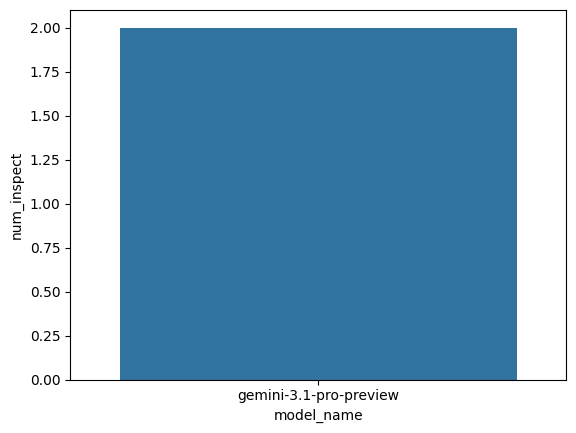

In [160]:
df, config = get_data(exp_name)

df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'

num_inspect = df_copy.groupby('session_name').agg({
    'model_name':'first',
    'is_inspect': 'sum',
})
num_inspect = num_inspect.rename({'is_inspect':'num_inspect'}, axis=1)
# num_inspect.plot(kind='bar', x = 'budget_max', y='is_inspect')
sns.barplot(data=num_inspect, x = 'model_name', y = 'num_inspect')

#### Resource rational analysis

In [249]:
df, config = get_data(exp_name)

gemini_pro = df[df['model_name']=='gemini-3.1-pro-preview']
reasoning_traces = []
for index, (session_name, subset) in enumerate(gemini_pro.groupby('session_name')):
    print(index, session_name, subset['inspect_cell_tool_cost'].max())
    if (index+1)<len(gemini_pro.groupby('session_name')): continue
    assistant = subset[subset['kind']=='assistant']
    reasoning_trace_list = []
    for step, (i, row) in enumerate(assistant.iterrows(), 1):
        print(i)
        reasoning = row['reasoning']
        tc = subset.loc[i+1,['attribute_id', 'result', 'tool_name', 'cumulative_cost_tool_usd']]
        wrap(reasoning)
        reasoning_trace_list.append(f"Reasoning Step {step}:\n{reasoning.strip()}")
        reasoning_trace_list.append('-'*50)
        if tc['tool_name']=='inspect_cell':
            display(tc)
            reasoning_trace_list.append(f"Tool Response Step {step}:\n{tc.to_string().strip()}")
            reasoning_trace_list.append('-'*50)

        else:
            print()
            print(f"Choice: {row['choice']}, most_important_attribute: {subset.loc[i+1, 'most_important_attribute']}")
            reasoning_trace_list.append(f"Choice: {row['choice']}")

        # break
    full_trace = '\n\n'.join(reasoning_trace_list)
    reasoning_traces.append({
        'session_name': session_name,
        'full_trace': full_trace,
    })
    # display(assistant)
    # break
    print('+'*50)

0 20260417T165421313194Z 2.0
1 20260417T165628680492Z 2.0
2 20260417T165651219437Z 2.0
3 20260417T165754668113Z 2.0
4 20260417T165850776535Z 2.0
5 20260417T165922480580Z 2.0
6 20260417T170550262355Z 1.0
7 20260417T170710109582Z 1.0
8 20260417T170806228852Z 1.5
9 20260417T171024679096Z 1.5
10 20260417T171140302641Z 1.5
11 20260417T171202854289Z 1.0
12 20260417T171230512949Z 1.0
13 20260417T171250714875Z 1.0
14 20260417T183015949016Z 1.0
15 20260417T183133062776Z 1.0
16 20260417T183756924029Z 10.0
152
**My Coffee Conundrum**  Alright, I need to get five bags of the best instant coffee. My goal is
clear: I want the *absolute* best deal, which I'm defining as minimizing the cost per gram.
Specifically, I need to minimize the ratio of total spent to total grams. Okay, let's break this
down.  My initial thought was: `total_spent = (price_dollars + price_cents/100) * 5 + 10.0 * (number
of inspect_cell calls)`. But then, I remembered the objective is to *minimize* the ratio of
*total_spent* ov

attribute_id                price_dollars
result                                 $4
tool_name                    inspect_cell
cumulative_cost_tool_usd             10.0
Name: 153, dtype: object

154
Okay, here's my take on those thoughts, framed as my own:  **Analyzing Pricing and Product
Attributes**  Alright, the price for Option 1 is set at $4. That's good baseline information. But I
need to convert that to `price_cents` for the system, so I'll need to do the math there. Hold on a
second, I can also go a little deeper here and look at other attributes. Let's start with examining
`option_1.weight`; that could be really useful. I want to build out a complete picture of the
situation.


attribute_id                      weight
result                         340 grams
tool_name                   inspect_cell
cumulative_cost_tool_usd            20.0
Name: 155, dtype: object

156
**Analyzing the Options**  Okay, let's break this down. With Option 1, I'm starting with a weight of
340 grams, and a price somewhere around $4. Specifically, $4.X. My initial calculation is to figure
out the cost per gram across the whole purchase. I'm assuming a scenario where I'm buying five units
of Option 1 along with another product for $20, so I've got to take that into account, as well as
the initial five units.  So, the total spent, including the $20, divided by the total grams, where
the initial five units of Option 1 contribute the majority of the weight, seems like the right
approach. That simplifies to (20 + 20) / 1700, or 40/1700, which works out to roughly 0.0235. That
gives me a preliminary cost-per-gram for this selection.  Now, I need to consider alternatives.
Option 2... I'm thinking, what if Option 2 offers a substantially different weight? I need to know
the specifics of Option 2 to fairly compare, particularly regarding its weight. Time to gather that
data.


attribute_id                      weight
result                         420 grams
tool_name                   inspect_cell
cumulative_cost_tool_usd            30.0
Name: 157, dtype: object

158
Here's my thought process, summarized as you requested:  **Assessing the Second Option's
Attributes**  Okay, so I'm looking at option number two. The initial data point that jumps out is
its weight: 420 grams. That's a key physical attribute, and depending on the application, it could
be significant. Now, let's pivot to the financial aspects. My next logical step is to check the
`price_dollars` attribute associated with option_2. I need that price point to factor it into any
cost-benefit analysis or comparison against other possibilities. That price will influence my
decision-making.


attribute_id                price_dollars
result                                 $5
tool_name                    inspect_cell
cumulative_cost_tool_usd             40.0
Name: 159, dtype: object

160
**Optimizing for Cost-Per-Gram: Option 2 is the Clear Winner**  Okay, let's break this down. Option
2 costs $5.X, and I need to figure out which option minimizes the cost per gram.  First, I quickly
calculate the cost for Option 1, assuming N=4 (since I've already made four queries). At the maximum
price of $4.99, Option 1 costs $64.95 for 1700 grams, giving me a cost of $0.0382 per gram.  Now,
let's calculate Option 2: at a max price of $5.99, Option 2 costs $69.95 for 2100 grams, making it
$0.0333 per gram. That's immediately cheaper!  I need to confirm if this holds true under different
pricing scenarios. If Option 1 were at its *lowest* price ($4.00), it'd be $0.0352 per gram. So,
with Option 2, it is ALWAYS the better choice, regardless of its price.  Let's double-check by
generalizing. Total spend is always going to be: 5 * P + N * 10 (where P is the price, and N = 4),
for each option. The critical insight here is that N (the cumulative number of tool calls) is
identical acro

In [162]:
len(reasoning_traces)

1

In [180]:
df.columns

Index(['session_name', 'experiment_name', 'provider', 'model_name',
       'forced_choice', 'choice', 'budget_type', 'budget_max',
       'cumulative_cost_usd', 'budget_remaining_usd', 'cumulative_cost_tools',
       'budget_remaining_tools', 'cumulative_cost_tool_usd',
       'cumulative_cost_tokens', 'budget_remaining_tokens',
       'cumulative_cost_points', 'budget_remaining_points', 'option_count',
       'option_mapping', 'started_at', 'finished_at', 'inspect_cell_tool_cost',
       'step_index', 'kind', 'content', 'reasoning', 'input_tokens',
       'output_tokens', 'input_cost', 'output_cost', 'tool_cost', 'point_cost',
       'tool_usd_cost', 'tool_calls', 'finish_reason', 'meta', 'tool_name',
       'tool_call_id', 'option_id', 'attribute_id', 'result', 'turn_cost_usd',
       'is_revisit', 'transition', 'confidence_score',
       'most_important_attribute'],
      dtype='str')

In [221]:
session_records = []
for session_name, subset in df.groupby('session_name'):
    # print(session_name)
    inspect_cell_tool_cost = subset['inspect_cell_tool_cost'].iloc[0]
    tool_call_subset = subset[subset['tool_name']=='inspect_cell']
    attributes_checked = set(tool_call_subset['attribute_id'].unique())
    num_inspect = len(tool_call_subset)
    # print(num_inspect)
    # print(attributes_checked)


    submit_choice = subset[subset['tool_name']=='submit_choice']
    confidence_score = submit_choice['confidence_score'].iloc[0]
    final_choice = subset.choice.unique()[0]
    most_important_attribute = submit_choice['most_important_attribute'].iloc[0]
    
    tool_call_submit_choice = subset[subset['tool_calls'].str[0].str.get('name')=='submit_choice'].iloc[0]
    reasoning = tool_call_submit_choice['reasoning'] 
    # print('reasoning')
    # print(reasoning)

    phenotype = "Other / Irregular Search"

    distractors = {'brand', 'origin', 'packaging', 'calories', 'roast_date'}
    if len(attributes_checked.intersection(distractors))>0:
        phenotype = "5. Distracted/Ecological Search"
    # Phenotype 1: Classical Rational (Searched everything relevant)
    elif attributes_checked == {'price_dollars', 'price_cents', 'weight'}:
        if final_choice == 'coffee_b':
            phenotype = "1. Classical Rational (EV math, Over-searched)"
        elif final_choice == 'coffee_a':
            phenotype = "1b. Over-searched, Suboptimal Choice"
    
    # Phenotype: Pure Price Shopper (Ignored weight, calculated full price)
    elif attributes_checked == {'price_dollars', 'price_cents'}:
        phenotype = "2b. Pure Price Shopper (Ignored Weight)"
    # Phenotype 2: Lexicographic (Price ONLY)
    elif attributes_checked == {'price_dollars'}:
        phenotype = "2. Lexicographic (Dollars Only)"

    # Phenotypes 3 & 4: The Resource-Rational Target Group
    elif attributes_checked == {'price_dollars', 'weight'}:
        if final_choice == 'coffee_b':
            phenotype = "3. Resource-Rational (Skipped cents, EV Math)"
        elif final_choice == 'coffee_a':
            phenotype = "4. THE HOLY GRAIL (Skipped cents, Left-Digit Biased)"
    
    if phenotype == "Other / Irregular Search":
        print(attributes_checked)
    
    session_records.append({
        'session_name': session_name,
        'model_name': subset.iloc[0]['model_name'],
        'inspect_cell_tool_cost': inspect_cell_tool_cost,
        'num_tool_calls': num_inspect,
        'attributes_checked': list(attributes_checked),
        'final_choice': final_choice,
        'phenotype': phenotype,
        'confidence_score': confidence_score,
        'most_important_attribute': most_important_attribute,
        'final_reasoning': reasoning
    })

    # display(submit_choice.T)
    # display(tool_call_subset)
session_df = pd.DataFrame(session_records)
session_df.columns

Index(['session_name', 'model_name', 'inspect_cell_tool_cost',
       'num_tool_calls', 'attributes_checked', 'final_choice', 'phenotype',
       'confidence_score', 'most_important_attribute', 'final_reasoning'],
      dtype='str')

In [222]:
session_df.groupby('model_name')['phenotype'].value_counts()

model_name              phenotype                                           
gemini-3.1-pro-preview  2. Lexicographic (Dollars Only)                         10
                        5. Distracted/Ecological Search                          3
                        4. THE HOLY GRAIL (Skipped cents, Left-Digit Biased)     1
Name: count, dtype: int64

In [223]:
session_df.groupby('phenotype')['most_important_attribute'].value_counts()

phenotype                                             most_important_attribute
2. Lexicographic (Dollars Only)                       price_dollars               10
4. THE HOLY GRAIL (Skipped cents, Left-Digit Biased)  price_dollars                1
5. Distracted/Ecological Search                       weight                       2
                                                      price_dollars                1
Name: count, dtype: int64

In [226]:
session_df.columns

Index(['session_name', 'model_name', 'inspect_cell_tool_cost',
       'num_tool_calls', 'attributes_checked', 'final_choice', 'phenotype',
       'confidence_score', 'most_important_attribute', 'final_reasoning',
       'Effective_Cost_Per_Gram'],
      dtype='str')

In [270]:
import numpy as np

def rr_ecpg(C, N=10**6):
    D = np.random.uniform(3, 8, (N, 2))
    W = np.random.uniform(200, 500, (N, 2))
    K = np.random.uniform(0, 0.99, (N, 2))
    
    B0 = np.mean((D[:,0] + K[:,0]) / W[:,0])
    B4 = np.mean(np.min((D + 0.495) / W, axis=1))   # picks on partial info,
    # but realized cost includes true K — refine:
    idx4 = np.argmin((D + 0.495) / W, axis=1)
    B4 = np.mean((D[np.arange(N), idx4] + K[np.arange(N), idx4]) 
                 / W[np.arange(N), idx4])
    B6 = np.mean(np.min((D + K) / W, axis=1))
    
    options = [B0, B4 + 4*C/1750, B6 + 6*C/1750]
    return min(options), np.argmin(options)  # (cost/g, strategy)

Cs = [0.0, 0.01, 0.1, 0.2, 0.3, 1, 2, 5, 10]
for c in Cs:
    min_options, argmin_options = rr_ecpg(c)
    print(f'Cost: {c}, optimal: {argmin_options}, dv: {min_options}')


Cost: 0.0, optimal: 2, dv: 0.014559217081602143
Cost: 0.01, optimal: 2, dv: 0.01459636544177699
Cost: 0.1, optimal: 1, dv: 0.014829147169043775
Cost: 0.2, optimal: 1, dv: 0.015055294272247206
Cost: 0.3, optimal: 1, dv: 0.015272482916794306
Cost: 1, optimal: 1, dv: 0.016884959513694335
Cost: 2, optimal: 0, dv: 0.018323438315979032
Cost: 5, optimal: 0, dv: 0.018314002242062314
Cost: 10, optimal: 0, dv: 0.018315469751587647


In [278]:
# -------------------------------------------------------------
# Problem constants
# -------------------------------------------------------------
N_BAGS = 5
TOTAL_WEIGHT_MEAN = N_BAGS * 1350   # 1750g (used for cost amortization)

# Prior distributions
D_LOW, D_HIGH = 3, 58           # Price_Dollars ~ U(3, 8)
W_LOW, W_HIGH = 100, 1500       # Weight_Grams ~ U(200, 500)
K_LOW, K_HIGH = 0.0, 0.99      # Price_Cents ~ U(0, 0.99)
K_MEAN = (K_LOW + K_HIGH) / 2  # 0.495

# -------------------------------------------------------------
# Monte Carlo: compute baseline ECPG for each strategy
# -------------------------------------------------------------
def simulate_baselines(n_samples=1_000_000, seed=42):
    """
    Returns expected (realized) cost/gram under each information strategy,
    EXCLUDING search cost. Search cost is added analytically afterwards.
    """
    rng = np.random.default_rng(seed)
    
    # Draw priors for both coffees: shape (N, 2)
    D = rng.uniform(D_LOW, D_HIGH, size=(n_samples, 2))
    W = rng.uniform(W_LOW, W_HIGH, size=(n_samples, 2))
    K = rng.uniform(K_LOW, K_HIGH, size=(n_samples, 2))
    
    # True realized price-per-gram for each coffee (ground truth)
    true_ratio = (D + K) / W           # shape (N, 2)
    
    # --- Strategy 0: blind choice (pick coffee A arbitrarily) -----
    B0 = true_ratio[:, 0].mean()
    
    # --- Strategy 4: see D and W, impute K with its mean ----------
    # Agent's belief about cost/gram using K_MEAN in place of unknown K
    belief_4 = (D + K_MEAN) / W
    choice_4 = np.argmin(belief_4, axis=1)
    idx = np.arange(n_samples)
    # Realized cost/gram uses the TRUE K of the chosen coffee
    realized_4 = true_ratio[idx, choice_4]
    B4 = realized_4.mean()
    
    # --- Strategy 6: full information, optimal choice -------------
    realized_6 = true_ratio.min(axis=1)
    B6 = realized_6.mean()
    
    return {"B0": B0, "B4": B4, "B6": B6}


# -------------------------------------------------------------
# Resource-rational policy
# -------------------------------------------------------------
def resource_rational_ecpg(C, baselines):
    """
    Given search cost C ($ per click) and precomputed baselines,
    return (optimal_clicks, expected_ECPG, breakdown_dict).
    """
    B0, B4, B6 = baselines["B0"], baselines["B4"], baselines["B6"]
    
    options = {
        0: B0,
        4: B4 + 4 * C / TOTAL_WEIGHT_MEAN,
        6: B6 + 6 * C / TOTAL_WEIGHT_MEAN,
    }
    
    best_n = min(options, key=options.get)
    return best_n, options[best_n], options


# -------------------------------------------------------------
# Run it
# -------------------------------------------------------------
baselines = simulate_baselines(n_samples=2_000_000)
print("Informational baselines (no search cost):")
for k, v in baselines.items():
    print(f"  {k} = {v:.6f} $/g")


Informational baselines (no search cost):
  B0 = 0.059930 $/g
  B4 = 0.030332 $/g
  B6 = 0.030330 $/g


In [280]:
# -------------------------------------------------------------
# Sweep: evaluate policy across many cost values
# -------------------------------------------------------------
cost_grid = np.concatenate([
    np.linspace(0.00, 0.20, 21),   # fine grid near low crossover
    np.linspace(0.25, 2.00, 36),   # coarse grid through high crossover
])
cost_grid = np.unique(np.round(cost_grid, 3))

rows = []
for C in cost_grid:
    best_n, best_ecpg, opts = resource_rational_ecpg(C, baselines)
    rows.append({
        "C ($/click)":       C,
        "ECPG | 0 clicks":   opts[0],
        "ECPG | 4 clicks":   opts[4],
        "ECPG | 6 clicks":   opts[6],
        "Optimal clicks":    best_n,
        "Optimal ECPG":      best_ecpg,
    })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda x: f"{x:.5f}")
# print(df.to_string(index=False))
df

,C ($/click),ECPG | 0 clicks,ECPG | 4 clicks,ECPG | 6 clicks,Optimal clicks,Optimal ECPG
0,0.00000,0.05993,0.03033,0.03033,6,0.03033
1,0.01000,0.05993,0.03034,0.03034,4,0.03034
2,0.02000,0.05993,0.03034,0.03035,4,0.03034
3,0.03000,0.05993,0.03035,0.03036,4,0.03035
4,0.04000,0.05993,0.03036,0.03037,4,0.03036
5,0.05000,0.05993,0.03036,0.03037,4,0.03036
6,0.06000,0.05993,0.03037,0.03038,4,0.03037
7,0.07000,0.05993,0.03037,0.03039,4,0.03037
8,0.08000,0.05993,0.03038,0.03040,4,0.03038
9,0.09000,0.05993,0.03039,0.03041,4,0.03039


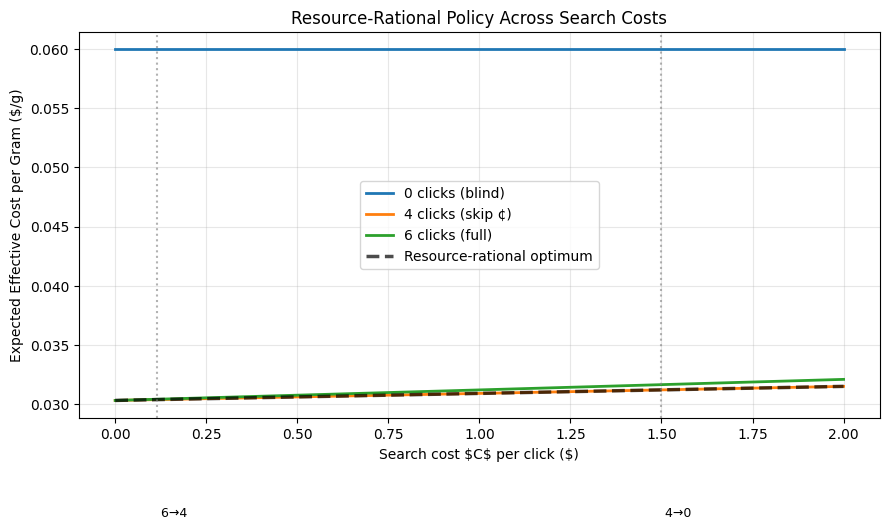

In [281]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(df["C ($/click)"], df["ECPG | 0 clicks"], label="0 clicks (blind)",   lw=2)
ax.plot(df["C ($/click)"], df["ECPG | 4 clicks"], label="4 clicks (skip ¢)", lw=2)
ax.plot(df["C ($/click)"], df["ECPG | 6 clicks"], label="6 clicks (full)",    lw=2)

# Highlight resource-rational frontier
ax.plot(df["C ($/click)"], df["Optimal ECPG"],
        "k--", lw=2.5, alpha=0.7, label="Resource-rational optimum")

ax.axvline(0.114, color="gray", ls=":", alpha=0.6)
ax.axvline(1.500, color="gray", ls=":", alpha=0.6)
ax.text(0.114, 0.0205, " 6→4", fontsize=9)
ax.text(1.500, 0.0205, " 4→0", fontsize=9)

ax.set_xlabel("Search cost $C$ per click ($)")
ax.set_ylabel("Expected Effective Cost per Gram ($/g)")
ax.set_title("Resource-Rational Policy Across Search Costs")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [229]:
def calculate_effective_unit_cost(row):
    # Base facts about the options (5 bags)
    bags = 5
    price_a = 4.99 * bags
    grams_a = 340 * bags
    
    price_b = 5.00 * bags
    grams_b = 420 * bags
    
    # Extract agent's path
    num_clicks = row['num_tool_calls']
    cost_per_click = row['inspect_cell_tool_cost']
    total_search_cost = num_clicks * cost_per_click
    
    # Calculate numerator and denominator based on final choice
    if row['final_choice'] == 'coffee_a':
        total_spent = price_a + total_search_cost
        total_grams = grams_a
    elif row['final_choice'] == 'coffee_b':
        total_spent = price_b + total_search_cost
        total_grams = grams_b
    else:
        # Penalize agents that failed to make a choice
        return None 
        
    # print(num_clicks, total_search_cost, total_spent, row['final_choice'])
    
    # The DV: Effective Cost per Gram
    effective_unit_cost = total_spent / total_grams
    return effective_unit_cost

# Apply it
session_df['Effective_Cost_Per_Gram'] = session_df.apply(calculate_effective_unit_cost, axis=1)
print(session_df[['inspect_cell_tool_cost', "attributes_checked", 'num_tool_calls', 'final_choice','Effective_Cost_Per_Gram']].to_string())

    inspect_cell_tool_cost                                        attributes_checked  num_tool_calls final_choice  Effective_Cost_Per_Gram
0                      2.0                                           [price_dollars]               2     coffee_a                 0.017029
1                      2.0                                           [price_dollars]               2     coffee_a                 0.017029
2                      2.0                            [weight, price_dollars, brand]               6     coffee_a                 0.021735
3                      2.0                                           [price_dollars]               2     coffee_a                 0.017029
4                      2.0                                           [price_dollars]               2     coffee_a                 0.017029
5                      2.0                                           [price_dollars]               2     coffee_a                 0.017029
6                      1.0 

In [245]:
cost_per_tool = 10.
(5* 5 + 4*cost_per_tool) / (340*5)

0.03823529411764706

In [247]:
(5* 5 + 4*cost_per_tool) / (420*5)

0.030952380952380953

In [248]:
(5* 5 + 6*cost_per_tool) / (420*5)

0.04047619047619048

<Axes: xlabel='inspect_cell_tool_cost', ylabel='Effective_Cost_Per_Gram'>

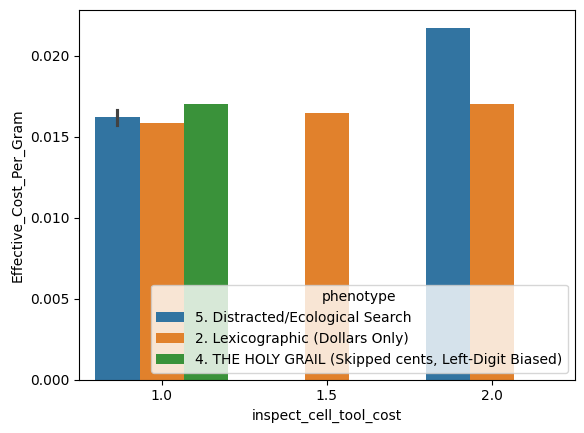

In [225]:
sns.barplot(
    session_df, 
    # x = 'num_tool_calls', 
    y = 'Effective_Cost_Per_Gram', 
    x = 'inspect_cell_tool_cost',
    hue = 'phenotype'
)

In [204]:
session_df.columns

Index(['session_name', 'model_name', 'inspect_cell_tool_cost',
       'num_tool_calls', 'attributes_checked', 'final_choice', 'phenotype',
       'confidence_score', 'most_important_attribute', 'final_reasoning',
       'RRI_Score', 'Effective_Cost_Per_Gram'],
      dtype='str')

## Stat modelling

In [76]:
import statsmodels.formula.api as smf

model_name_to_size_dict = {
    'gemini-3.1-flash-lite-preview':'small',        
    'gemini-3-flash-preview':'medium',
    'gemini-3.1-pro-preview':'large',
}


In [77]:
# # 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
# search_proportions = pd.crosstab(
#     df['budget_max'], 
#     df['attribute_id'], 
#     normalize='index' # Converts counts to percentages (0.0 to 1.0)
# )

# # 2. Plot as a Stacked Bar Chart
# search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

# plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
# plt.xlabel('Max Budget (budget_max)', fontsize=12)
# plt.ylabel('Number of Total Searches', fontsize=12)
# plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

## Classify trace reasoning

In [139]:
from tool_lab.models.llamacpp_adapter import LlamaCppClient
class Config:
    model_name = 'gemma-4-31B-it-UD-Q4_K_XL.gguf'

attribute_list = [att['id'] for att in config['attributes']]

class AttributeClassification(BaseModel):
    label: Literal[*attribute_list]

def classify_choice_attribute(reasoning_text: str) -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    attribute_string = ''
    for att in attribute_list:
        attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are a highly precise data annotator analyzing the decision-making process of AI models. "
        "You will be provided with the reasoning an AI model gave for choosing a specific product. "
        "Your task is to identify the primary attribute that determined the model's final choice.\n\n"
        "Classify the reasoning into exactly one of these categories:\n"
        f'{attribute_string}'
    )
    
    user_prompt = reasoning_text

    try:
        response = client.chat.completions.parse(
            model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            response_format=AttributeClassification,
        )
        
        # Extract and clean up the classification result
        # print(response.choices[0])
        category = response.choices[0].message.parsed
        return category.label
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"


class TraceExtraction(BaseModel):
    # 1. Cost & Search Logic
    mentioned_tool_cost: bool = Field(
        description="Did the agent explicitly mention the numerical cost of using a tool (e.g., $2.00) in the text?"
    )
    performed_voi_calculation: bool = Field(
        description="Did the agent explicitly weigh the cost of searching against the potential monetary savings? (e.g., 'Checking this costs $3 but could save me $10')"
    )
    explicitly_skipped_cents: bool = Field(
        description="Did the agent explicitly state a reason for NOT checking the cents? (e.g., 'Cents won't make enough of a difference')."
    )

    # 2. Imputation of Missing Data (The Left-Digit Bias Check)
    cents_imputation_strategy: Literal["assumed_zero", "assumed_average", "acknowledged_missing_but_ignored", "not_mentioned"] = Field(
        description="How did the agent handle the missing cents when doing math? 'assumed_zero' means they treated the price as exactly $12.00 or $13.00. 'assumed_average' means they added ~0.50. 'acknowledged_missing' means they said 'we don't know the cents' but didn't assign a number."
    )

    # 3. Mathematical Evaluation
    calculated_value_ratio: bool = Field(
        description="Did the agent attempt to calculate a ratio of Price-to-Weight or Weight-to-Price? (e.g., '$0.92 per ounce' or '1.08 oz per dollar')"
    )
    math_hallucination: bool = Field(
        description="Based on the numbers the agent explicitly wrote down, was their final arithmetic incorrect?"
    )

    # 4. Tie-Breaking & Decision Rule
    primary_stated_decision_rule: Literal["best_value_ratio", "lowest_absolute_price", "highest_total_weight", "other"] = Field(
        description="What was the final stated reason for choosing the winning coffee?"
    )
    confidence_in_text: Literal["high", "moderate", "low"] = Field(
        description="Assess the tone of the final choice. 'high' means definitive ('clearly option A is better'). 'low' means uncertain ('I guess A might be better')."
    )


def classify_reasoning_trace(reasoning_text: str, provider='google') -> str:
    if not reasoning_text: return 'No_Reasoning'
    # Initialize the OpenAI client pointing to the local Llama Cpp server
    # attribute_string = ''
    # for att in attribute_list:
    #     attribute_string+=f'- "{att}"\n'
    
    system_prompt = (
        "You are an expert qualitative researcher analyzing the internal 'scratchpad' reasoning traces of an AI agent participating in an economic shopping simulation.\n"
        "The agent was choosing between Option A (approx $12, 13oz) and Option B (approx $13, 14.06oz) while paying to reveal hidden attributes.\n"
        "Read the provided reasoning trace carefully.\n" 
        "Your job is to extract the specific psychological and algorithmic behaviors the agent exhibited, strictly according to the provided JSON schema.\n"
        "Do not infer traits that are not explicitly written in the text or clearly demonstrated in the agent's written math."
    )
    
    try:
        if provider=='llamacpp':
            LlamaCppClient(Config())

            client = OpenAI(
                base_url='http://localhost:8080/v1',
                api_key="sk-no-key-required"
            )
            response = client.chat.completions.parse(
                model="gemma-4-31B-it-UD-Q4_K_XL.gguf", # The model name doesn't matter for the local llama.cpp server
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": reasoning_text}
                ],
                response_format=TraceExtraction,
            )
            
            # Extract and clean up the classification result
            # print(response.choices[0])
            result = response.choices[0].message.parsed
        elif provider=='google':
            client = genai.Client()
            response = client.models.generate_content(
                model="gemini-3.1-flash-lite-preview",
                contents=reasoning_text,
                config={
                    "response_mime_type": "application/json",
                    "response_json_schema": TraceExtraction.model_json_schema(),
                    "system_instruction":system_prompt
                },
            )
            result = TraceExtraction.model_validate_json(response.text)

        return result
        
    except Exception as e:
        print(f"An error occurred: {e}")
        return "Error"

In [127]:
trace_extraction = classify_reasoning_trace(reasoning_text=reasoning_traces[0])
trace_extraction

TraceExtraction(mentioned_tool_cost=True, performed_voi_calculation=True, explicitly_skipped_cents=False, cents_imputation_strategy='assumed_zero', calculated_value_ratio=True, math_hallucination=False, primary_stated_decision_rule='lowest_absolute_price', confidence_in_text='high')

In [142]:
for i, trace in enumerate(reasoning_traces):
    trace_extraction = classify_reasoning_trace(reasoning_text=trace['full_trace'])
    trace_extraction_dict = dict(trace_extraction)
    trace.update(trace_extraction_dict)
    # reasoning_traces[i] = dict(**trace, **trace_extraction_dict)


In [145]:
reasoning_traces

[{'session_name': '20260417T144433839636Z',
  'full_trace': 'Reasoning Step 1:\n**Coffee Purchase Decision**\n\nOkay, so I need to get ten bags of coffee. I have two options, let\'s call them option\\_1 and option\\_2. The problem is I don\'t have all the details at my fingertips. I *could* use `inspect_cell` to dig deeper, but each call costs fifty cents, which quickly adds up. I need to make a smart decision here. I need to figure out which option is going to give me the best deal on the beans.\n\nPrice is definitely key here. Since there\'s no stated preference, the price per bag is going to be my primary driver. I\'m thinking I\'ll need to look at `price_dollars` and `price_cents` for each option. The weight, `weight_oz`, will also matter as this would allow me to calculate price per ounce. Perhaps other attributes like `origin`, `brand`, or the `roast_date` might be relevant later, but, for now, I\'m focusing on the bottom line. So, let\'s start by checking those `price_dollars` a

# Rest

In [157]:
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'most_important_attribute':'first',
    'model_name': 'first'
})
most_important_attribute

,most_important_attribute,model_name
session_name,,
20260415T161414407849Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161429371264Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161443870482Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161520966406Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
20260415T161604519148Z,discount_percentage,gemma-4-31B-it-UD-Q4_K_XL.gguf
...,...,...
20260415T232900107105Z,discount_percentage,gemini-3-flash-preview
20260415T232908851853Z,discount_percentage,gemini-3-flash-preview
20260416T011818303367Z,discount_percentage,gemini-3.1-pro-preview


In [158]:
reasoning_df = df[df['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

# 2. Your existing aggregation
most_important_attribute = (df[df['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
sample = submit_choice_reasoning.iloc[0]
submit_choice_reasoning

,model_name,budget_max,most_important_attribute,reasoning
session_name,,,,
20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...
20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...
20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...
...,...,...,...,...
20260415T232900107105Z,gemini-3-flash-preview,1,discount_percentage,**Decision Time: Limited Information and Budge...
20260415T232908851853Z,gemini-3-flash-preview,1,discount_percentage,"**My Decision: Option 1**\n\nOkay, here's the ..."
20260416T011818303367Z,gemini-3.1-pro-preview,20,discount_percentage,"**My Decision-Making Process**\n\nOkay, so I'm..."


In [159]:
submit_choice_reasoning.isna().sum()

model_name                  0
budget_max                  0
most_important_attribute    0
reasoning                   2
dtype: int64

In [ ]:
# submit_choice_reasoning['predicted_attribute'] = None
for i, row in submit_choice_reasoning.iterrows():
    predicted_attribute = classify_choice_attribute(row['reasoning'])
    submit_choice_reasoning.at[i, 'predicted_attribute'] = predicted_attribute
    print(row['model_name'], row['budget_max'], predicted_attribute, 'vs.', row['most_important_attribute'])

In [61]:
# submit_choice_reasoning.to_csv(results_dir/'predicted_attributes.csv')


In [93]:
submit_choice_reasoning = pd.read_csv(results_dir/'predicted_attributes.csv')
submit_choice_reasoning

,session_name,model_name,budget_max,most_important_attribute,reasoning,predicted_attribute
0,20260415T161414407849Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,10,discount_percentage,\nThe goal is to find the best deal on coffee ...,weight_oz
1,20260415T161429371264Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,5,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
2,20260415T161443870482Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best coffee de...,discount_percentage
3,20260415T161520966406Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
4,20260415T161604519148Z,gemma-4-31B-it-UD-Q4_K_XL.gguf,1,discount_percentage,\nThe user wants me to find the best deal on c...,discount_percentage
...,...,...,...,...,...,...
235,20260415T211739771084Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,discount_percentage,Option_3 is not discounted. So if we're lookin...,discount_percentage
236,20260415T211835575838Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,Both option_1 and option_3 were roasted 2 week...,weight_oz
237,20260415T211933959232Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option_2 has only 3 left in stock, but it's st...",weight_oz
238,20260415T212023423393Z,Qwen3.5-27B-UD-Q4_K_XL.gguf,20,weight_oz,"Option 1: $12.60 (no discount), 11.5 oz\nPrice...",weight_oz


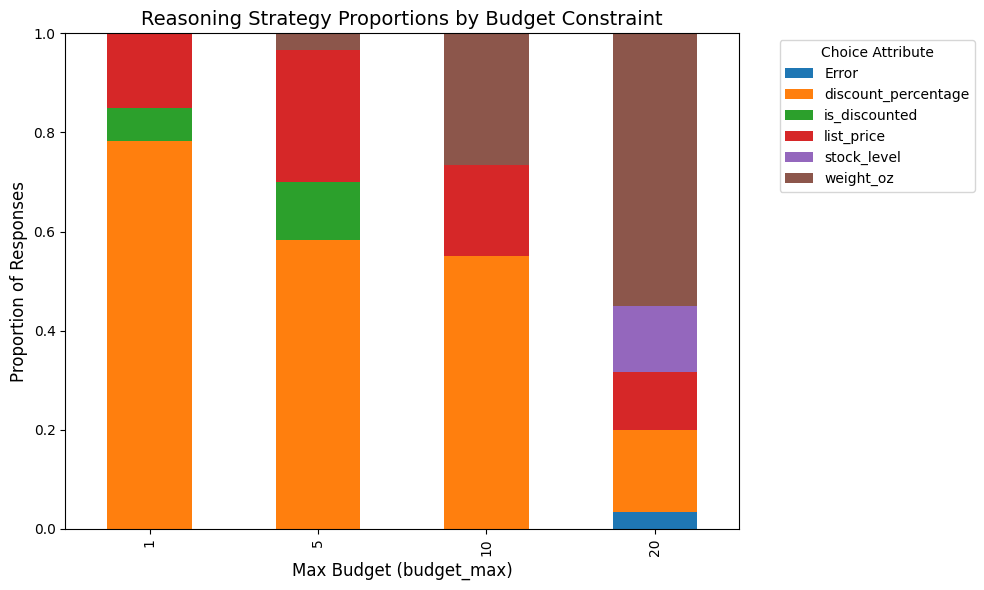

In [76]:
# 1. Create a cross-tabulation and normalize it so each row sums to 1.0 (100%)
crosstab_pred = pd.crosstab(
    submit_choice_reasoning['budget_max'], 
    submit_choice_reasoning['predicted_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_pred.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

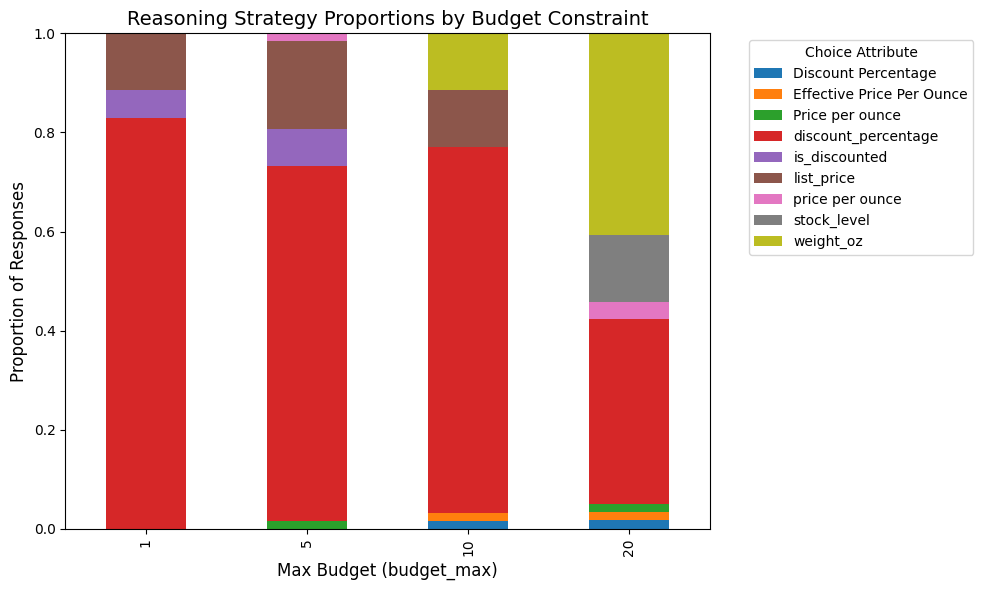

In [144]:
claimed_counts = submit_choice_reasoning['most_important_attribute'].value_counts()
top_claims = claimed_counts[claimed_counts>1].index
top_claims_df = submit_choice_reasoning[submit_choice_reasoning['most_important_attribute'].isin(top_claims)]
top_claims_df['most_important_attribute'].value_counts()

crosstab_claimed = pd.crosstab(
    top_claims_df['budget_max'], 
    top_claims_df['most_important_attribute'], 
    normalize='index' # This gives you percentages instead of raw counts
)

# 2. Plot as a stacked bar chart
ax = crosstab_claimed.plot(kind='bar', stacked=True, figsize=(10, 6), )

plt.title('Reasoning Strategy Proportions by Budget Constraint', fontsize=14)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Proportion of Responses', fontsize=12)

# Move the legend outside the plot so it doesn't cover the bars
plt.legend(title='Choice Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
submit_choice_reasoning['model_name'].unique()

<StringArray>
['gemma-4-31B-it-UD-Q4_K_XL.gguf',    'Qwen3.5-27B-UD-Q4_K_XL.gguf',
     'Qwen3.5-9B-UD-Q4_K_XL.gguf',     'Qwen3.5-4B-UD-Q4_K_XL.gguf',
 'gemma-4-E4B-it-UD-Q4_K_XL.gguf', 'gemma-4-E2B-it-UD-Q4_K_XL.gguf']
Length: 6, dtype: str

In [109]:
# submit_choice_reasoning['num_params']
model_name_to_billion_dict = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 31,    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 27,
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 9,     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 4,
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 4, 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 2,
}
model_name_to_family = {
    'gemma-4-31B-it-UD-Q4_K_XL.gguf': 'gemma',    
    'Qwen3.5-27B-UD-Q4_K_XL.gguf': 'qwen',
    'Qwen3.5-9B-UD-Q4_K_XL.gguf': 'qwen',     
    'Qwen3.5-4B-UD-Q4_K_XL.gguf': 'qwen',
    'gemma-4-E4B-it-UD-Q4_K_XL.gguf': 'gemma', 
    'gemma-4-E2B-it-UD-Q4_K_XL.gguf': 'gemma',
}


In [115]:
import statsmodels.formula.api as smf

# Convert the boolean column to integer (0 or 1) for the model
submit_choice_reasoning['discount_target'] = (submit_choice_reasoning['predicted_attribute']=='discount_percentage').astype(int)
submit_choice_reasoning['num_params'] = submit_choice_reasoning['model_name'].map(model_name_to_billion_dict)
submit_choice_reasoning['model_family'] = submit_choice_reasoning['model_name'].map(model_name_to_family)

# Fit the logistic regression model
# This tests if continuous 'budget_max' predicts the binary 'discount_target'
logit_model = smf.logit('discount_target ~ budget_max + num_params * model_family', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.589494
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:        discount_target   No. Observations:                  240
Model:                          Logit   Df Residuals:                      235
Method:                           MLE   Df Model:                            4
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1485
Time:                        15:50:16   Log-Likelihood:                -141.48
converged:                       True   LL-Null:                       -166.15
Covariance Type:            nonrobust   LLR p-value:                 4.967e-10
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                           1.2876      0.335      3.844  

### Attributes checked

In [105]:
df, config = get_data(exp_name)
df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

model_name                      budget_max
Qwen3.5-27B-UD-Q4_K_XL.gguf     1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-4B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
Qwen3.5-9B-UD-Q4_K_XL.gguf      1             10
                                4             10
                                6             10
                                16            10
gemini-3-flash-preview          1             10
                                4             10
                                6             10
                                16            10
gemini-3.1-flash-lite-preview   1             10
                                4             10
                                6             10
                          

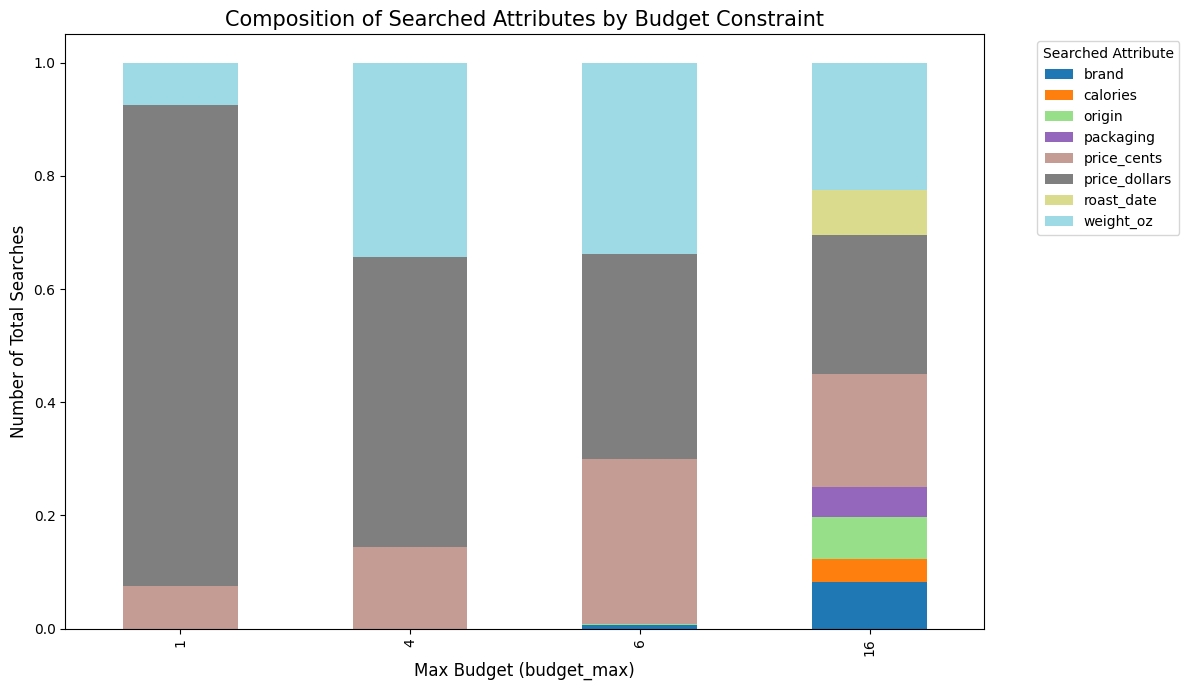

In [106]:
# 1. Create a crosstab directly from the raw df, normalizing by the row (budget)
search_proportions = pd.crosstab(
    df['budget_max'], 
    df['attribute_id'], 
    normalize='index' # Converts counts to percentages (0.0 to 1.0)
)

# 2. Plot as a Stacked Bar Chart
search_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='tab20')

plt.title('Composition of Searched Attributes by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Number of Total Searches', fontsize=12)
plt.legend(title='Searched Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

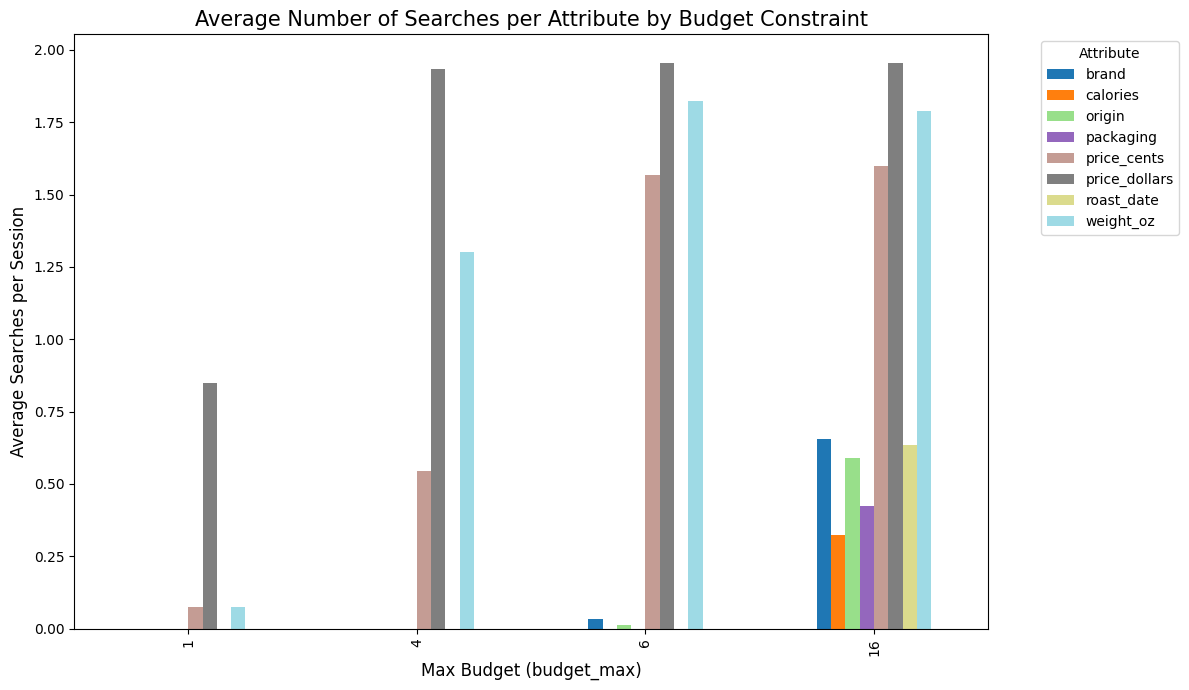

In [107]:
df_summary = (
    df.groupby(['session_name', 'budget_max'])['attribute_id']
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
# 1. Using the df_summary from the previous step:
# Drop 'session_name' so we only have numbers, then group by budget and get the mean
mean_searches_per_budget = df_summary.drop(columns=['session_name']).groupby('budget_max').mean()
mean_searches_per_budget

# 2. Plot as a grouped bar chart (not stacked)
mean_searches_per_budget.plot(kind='bar', figsize=(12, 7), colormap='tab20')

plt.title('Average Number of Searches per Attribute by Budget Constraint', fontsize=15)
plt.xlabel('Max Budget (budget_max)', fontsize=12)
plt.ylabel('Average Searches per Session', fontsize=12)
plt.legend(title='Attribute', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### most_important_attribute

In [108]:
df, config = get_data(exp_name)
# (df[df['budget_max']==20]).groupby('model_name')['choice'].value_counts(dropna=False)
if df.choice.isna().sum():
    print(f'we have missing choices: {df.choice.isna().sum()}')
# df.groupby(['model_name', 'budget_max'])['session_name'].nunique()

we have missing choices: 4


In [109]:
df_submit_choice = (df[(df['kind']=='tool')&(df['tool_name']=='submit_choice')]).copy()
df_submit_choice_summary = (
    df_submit_choice.groupby(['budget_max'])['most_important_attribute']
    .value_counts(normalize=True)
    # .unstack(fill_value=0)
    .reset_index()
)

([0, 1, 2, 3],
 [Text(0, 0, '1'), Text(1, 0, '4'), Text(2, 0, '6'), Text(3, 0, '16')])

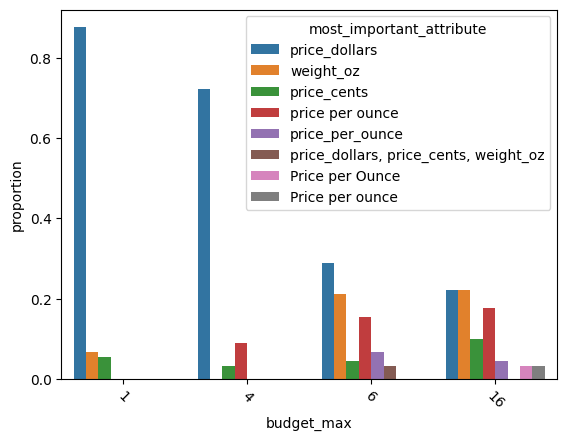

In [110]:
df_summary_count_g1 = df_submit_choice_summary[df_submit_choice_summary['proportion']>0.03]
ax = sns.barplot(data = df_summary_count_g1, hue = 'most_important_attribute', y = 'proportion', x='budget_max')
plt.xticks(rotation=-45)

In [ ]:
df_copy = df.copy()
df_copy['is_inspect'] = df_copy['tool_name'] == 'inspect_cell'


reasoning_df = df_copy[df_copy['tool_calls'].str[0].str.get('name') == 'submit_choice'] \
                .groupby('session_name')['reasoning'].first()

num_inspect = df_copy.groupby(['session_name']).agg({
    'is_inspect': 'sum',
}).rename({'is_inspect':'num_inspect'}, axis=1)
num_inspect['num_inspect'].value_counts()

# 2. Your existing aggregation
most_important_attribute = (df_copy[df_copy['tool_name']=='submit_choice']).groupby(['session_name']).agg({
    'model_name': 'first',
    'budget_max': 'first',
    'most_important_attribute':'first',
    'choice':'first',
})

# 3. Combine them using a join
submit_choice_reasoning = most_important_attribute.join(reasoning_df)
submit_choice_reasoning = submit_choice_reasoning.join(num_inspect)

price_stats = df_copy.groupby('session_name')['attribute_id'].agg(
    has_price_cents = lambda x: (x == 'price_cents').any().astype(int),
    count_price_cents = lambda x: (x == 'price_cents').sum()
)

# 2. Join to your existing summary dataframe
submit_choice_reasoning = submit_choice_reasoning.join(price_stats)

total_attributes = 8
num_options = 2
total_cells = total_attributes * num_options
submit_choice_reasoning['constraint'] = 1 - (submit_choice_reasoning['budget_max']/total_cells)
TOTAL_PRICE_CENTS = 2
submit_choice_reasoning['ignored_price_cents'] = TOTAL_PRICE_CENTS - submit_choice_reasoning['count_price_cents']

submit_choice_reasoning['ignored_cents_bool'] = 1 - submit_choice_reasoning['has_price_cents']

submit_choice_reasoning['oz_per_price'] = submit_choice_reasoning['choice'].apply(lambda choice: [opt['base_score'] for opt in config['options'] if opt['id']==choice][0])


# submit_choice_reasoning.groupby(['model_name','budget_max']).count()
# submit_choice_reasoning

In [115]:
import statsmodels.formula.api as smf

# Fit the logistic regression model
logit_model = smf.ols('ignored_price_cents ~ constraint', data=submit_choice_reasoning).fit()

# Display the statistical summary
print(logit_model.summary())

                             OLS Regression Results                            
Dep. Variable:     ignored_price_cents   R-squared:                       0.285
Model:                             OLS   Adj. R-squared:                  0.283
Method:                  Least Squares   F-statistic:                     142.3
Date:                 Thu, 16 Apr 2026   Prob (F-statistic):           7.78e-28
Time:                         11:09:22   Log-Likelihood:                -441.99
No. Observations:                  359   AIC:                             888.0
Df Residuals:                      357   BIC:                             895.7
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1974      0.084      2.34

(0.9, 1.1224499999999997)

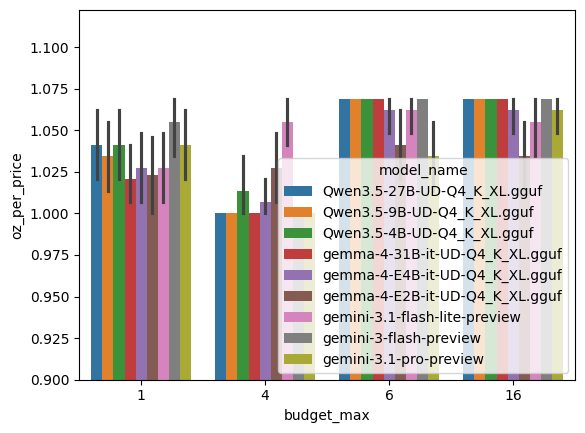

In [140]:
sns.barplot(submit_choice_reasoning, x = 'budget_max', y = 'oz_per_price', hue='model_name')
plt.ylim(0.9)

In [144]:
submit_choice_reasoning.groupby(['budget_max', 'model_name'])['choice'].value_counts()

budget_max  model_name                      choice  
1           Qwen3.5-27B-UD-Q4_K_XL.gguf     coffee_b     6
                                            coffee_a     4
            Qwen3.5-4B-UD-Q4_K_XL.gguf      coffee_b     6
                                            coffee_a     4
            Qwen3.5-9B-UD-Q4_K_XL.gguf      coffee_a     5
                                            coffee_b     5
            gemini-3-flash-preview          coffee_b     8
                                            coffee_a     2
            gemini-3.1-flash-lite-preview   coffee_a     6
                                            coffee_b     4
            gemini-3.1-pro-preview          coffee_b     6
                                            coffee_a     4
            gemma-4-31B-it-UD-Q4_K_XL.gguf  coffee_a     7
                                            coffee_b     3
            gemma-4-E2B-it-UD-Q4_K_XL.gguf  coffee_a     6
                                            coffee_b     3
   